In [16]:
# Cell 1: Install dependencies and load the dataset
!pip install -q kagglehub imbalanced-learn xgboost

import kagglehub
import pandas as pd
import numpy as np

# Download latest version of the dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

# The dataset folder contains creditcard.csv
import os
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print("\nClass balance:")
print(df["Class"].value_counts())
print("\nFraud rate: {:.4f}%".format(df["Class"].mean() * 100))

df.head()

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud
Shape: (284807, 31)

Class balance:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [17]:
# Cell 2: Train / Validation / Test split (stratified) + scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df.drop(columns=["Class"])
y = df["Class"]

# First split: 70% train, 30% temp (which becomes val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

# Second split: split the 30% temp into 15% val, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)

print("Train shape:", X_train.shape, "Fraud rate: {:.4f}%".format(y_train.mean()*100))
print("Val shape:  ", X_val.shape, "Fraud rate: {:.4f}%".format(y_val.mean()*100))
print("Test shape: ", X_test.shape, "Fraud rate: {:.4f}%".format(y_test.mean()*100))

# Scale Time and Amount (V1-V28 are already PCA-scaled)
scaler = StandardScaler()

cols_to_scale = ["Time", "Amount"]

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Fit scaler ONLY on training data, then apply to all three
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

X_train_scaled[["Time", "Amount"]].describe()

Train shape: (199364, 30) Fraud rate: 0.1725%
Val shape:   (42721, 30) Fraud rate: 0.1732%
Test shape:  (42722, 30) Fraud rate: 0.1732%


,Time,Amount
count,1.993640e+05,1.993640e+05
mean,-1.055671e-16,1.094163e-17
std,1.000003e+00,1.000003e+00
min,-1.998286e+00,-3.492566e-01
25%,-8.558564e-01,-3.268514e-01
50%,-2.116814e-01,-2.623226e-01
75%,9.363437e-01,-4.301173e-02
max,1.640221e+00,1.011706e+02


In [18]:
# Cell 3: SMOTE - full 50/50 balance, training set ONLY
from imblearn.over_sampling import SMOTE
from collections import Counter

print("Before SMOTE:", Counter(y_train))

smote = SMOTE(sampling_strategy=1.0, random_state=42)  # 1.0 = full 50/50 balance
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE: ", Counter(y_train_resampled))
print("\nNew train shape:", X_train_resampled.shape)

Before SMOTE: Counter({0: 199020, 1: 344})
After SMOTE:  Counter({0: 199020, 1: 199020})

New train shape: (398040, 30)


In [19]:
# Cell 4: Train 4 candidate models on the SMOTE-balanced training set,
# evaluate all of them on the (untouched, real-world-ratio) validation set

!pip install -q lightgbm

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, classification_report
)
import pandas as pd

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
}

results = []
fitted_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train_resampled, y_train_resampled)
    fitted_models[name] = model

    y_pred = model.predict(X_val_scaled)
    y_proba = model.predict_proba(X_val_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_proba),
        "PR-AUC": average_precision_score(y_val, y_proba),
    })

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
print("\n=== Validation Results (all models) ===")
results_df

Training Logistic Regression...
Training Random Forest...
Training XGBoost...
Training LightGBM...

=== Validation Results (all models) ===


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
3,LightGBM,0.998455,0.533898,0.851351,0.656250,0.978869,0.828870
2,XGBoost,0.999228,0.773333,0.783784,0.778523,0.978126,0.825063
1,Random Forest,0.999368,0.850746,0.770270,0.808511,0.958090,0.817272
0,Logistic Regression,0.977505,0.063913,0.878378,0.119157,0.966152,0.636045


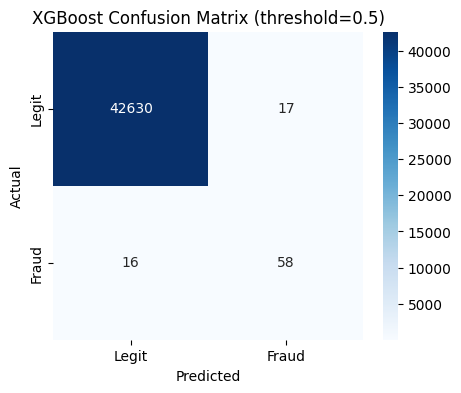

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     42647
       Fraud       0.77      0.78      0.78        74

    accuracy                           1.00     42721
   macro avg       0.89      0.89      0.89     42721
weighted avg       1.00      1.00      1.00     42721



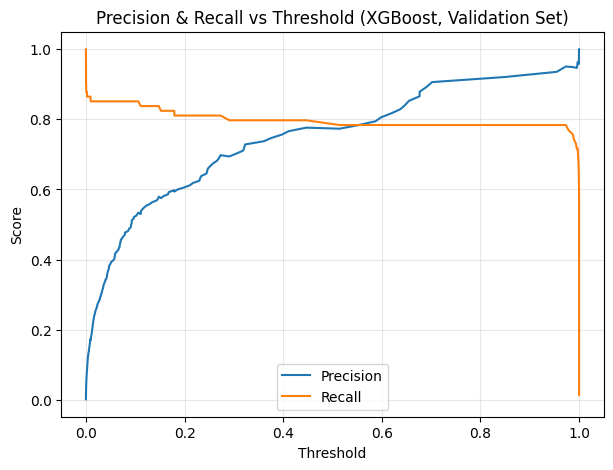


=== Threshold trade-off table ===


,Threshold,Precision,Recall,Flagged Count,True Frauds Caught
0,0.3,0.702381,0.797297,84,59
1,0.4,0.766234,0.797297,77,59
2,0.5,0.773333,0.783784,75,58
3,0.6,0.816901,0.783784,71,58
4,0.7,0.906250,0.783784,64,58
5,0.8,0.920635,0.783784,63,58
6,0.9,0.935484,0.783784,62,58


In [20]:
# Cell 5: Confusion matrix and threshold tuning for XGBoost

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve

best_model = fitted_models["XGBoost"]

# --- Confusion matrix at default 0.5 threshold ---
y_pred_default = best_model.predict(X_val_scaled)
cm = confusion_matrix(y_val, y_pred_default)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix (threshold=0.5)")
plt.show()

print(classification_report(y_val, y_pred_default, target_names=["Legit", "Fraud"]))

# --- Precision-Recall curve across thresholds ---
y_proba_val = best_model.predict_proba(X_val_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_val)

plt.figure(figsize=(7,5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision & Recall vs Threshold (XGBoost, Validation Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# --- Show precision/recall/flagged-volume at a few candidate thresholds ---
threshold_table = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_t = (y_proba_val >= t).astype(int)
    threshold_table.append({
        "Threshold": t,
        "Precision": precision_score(y_val, preds_t),
        "Recall": recall_score(y_val, preds_t),
        "Flagged Count": preds_t.sum(),
        "True Frauds Caught": ((preds_t == 1) & (y_val == 1)).sum(),
    })

threshold_df = pd.DataFrame(threshold_table)
print("\n=== Threshold trade-off table ===")
threshold_df

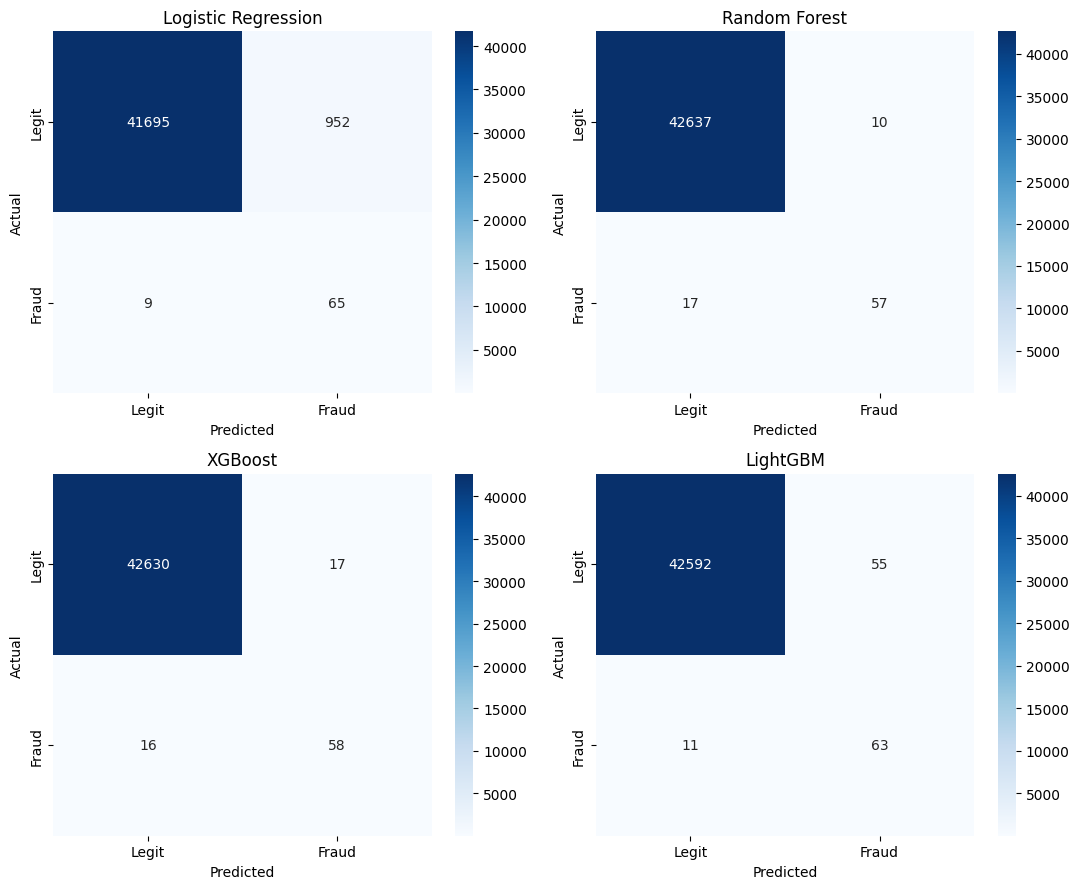

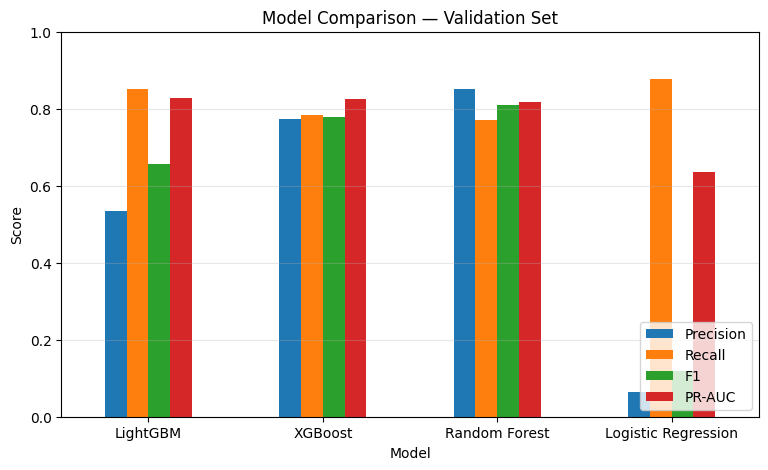

In [21]:
# Cell 5: Confusion matrices for all 4 models + metric comparison chart

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, (name, model) in zip(axes, fitted_models.items()):
    y_pred = model.predict(X_val_scaled)
    cm = confusion_matrix(y_val, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

# --- Bar chart comparing all metrics across all models ---
metrics_to_plot = ["Precision", "Recall", "F1", "PR-AUC"]
plot_df = results_df.set_index("Model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Model Comparison — Validation Set")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y", alpha=0.3)
plt.show()

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best parameters found:
{'subsample': 0.8, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 1.0}

Best CV PR-AUC score: 0.9999882522855206

=== Tuned XGBoost — Validation Performance ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     42647
       Fraud       0.85      0.81      0.83        74

    accuracy                           1.00     42721
   macro avg       0.92      0.91      0.91     42721
weighted avg       1.00      1.00      1.00     42721

PR-AUC: 0.8410916283536019
ROC-AUC: 0.979834138075046


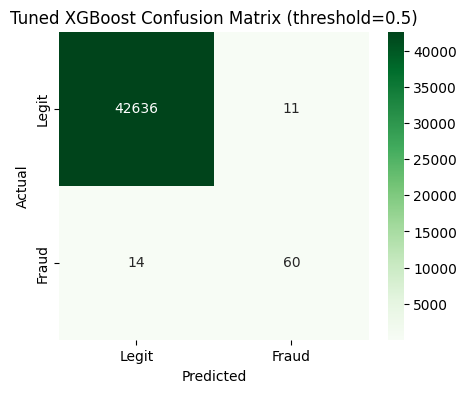

In [22]:
# Cell 6: Hyperparameter tuning for XGBoost via RandomizedSearchCV

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 4, 5, 6, 7],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5],
    "gamma": [0, 0.1, 0.3],
}

xgb_base = XGBClassifier(eval_metric="logloss", random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=25,                  # tries 25 random combinations
    scoring="average_precision",  # PR-AUC
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1,
)

random_search.fit(X_train_resampled, y_train_resampled)

print("Best parameters found:")
print(random_search.best_params_)
print("\nBest CV PR-AUC score:", random_search.best_score_)

# Evaluate the tuned model on the validation set
tuned_xgb = random_search.best_estimator_
y_pred_tuned = tuned_xgb.predict(X_val_scaled)
y_proba_tuned = tuned_xgb.predict_proba(X_val_scaled)[:, 1]

print("\n=== Tuned XGBoost — Validation Performance ===")
print(classification_report(y_val, y_pred_tuned, target_names=["Legit", "Fraud"]))
print("PR-AUC:", average_precision_score(y_val, y_proba_tuned))
print("ROC-AUC:", roc_auc_score(y_val, y_proba_tuned))

cm_tuned = confusion_matrix(y_val, y_pred_tuned)
plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned XGBoost Confusion Matrix (threshold=0.5)")
plt.show()

In [23]:
# Cell 8: Threshold trade-off table for tuned XGBoost + SMOTE

final_model = tuned_xgb  # from Cell 6 (RandomizedSearchCV best_estimator_, trained on SMOTE data)

y_proba_final = final_model.predict_proba(X_val_scaled)[:, 1]

threshold_table_final = []
for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    preds_t = (y_proba_final >= t).astype(int)
    threshold_table_final.append({
        "Threshold": t,
        "Precision": precision_score(y_val, preds_t),
        "Recall": recall_score(y_val, preds_t),
        "Flagged Count": preds_t.sum(),
        "True Frauds Caught": ((preds_t == 1) & (y_val == 1)).sum(),
    })

threshold_df_final = pd.DataFrame(threshold_table_final)
print("=== Threshold trade-off table — Tuned XGBoost + SMOTE ===")
threshold_df_final


=== Threshold trade-off table — Tuned XGBoost + SMOTE ===


,Threshold,Precision,Recall,Flagged Count,True Frauds Caught
0,0.3,0.779221,0.810811,77,60
1,0.4,0.821918,0.810811,73,60
2,0.5,0.845070,0.810811,71,60
3,0.6,0.882353,0.810811,68,60
4,0.7,0.895522,0.810811,67,60
5,0.8,0.906250,0.783784,64,58
6,0.9,0.950000,0.770270,60,57


=== FINAL MODEL — Test Set Performance (threshold=0.7) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00     42648
       Fraud       0.84      0.77      0.80        74

    accuracy                           1.00     42722
   macro avg       0.92      0.89      0.90     42722
weighted avg       1.00      1.00      1.00     42722

PR-AUC: 0.8280200209718862
ROC-AUC: 0.9731884388609208


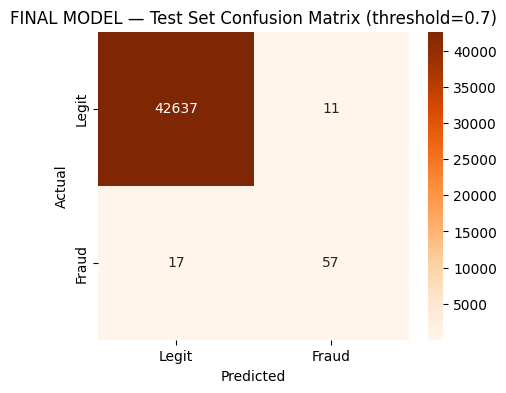

In [24]:
# Cell 9: Final evaluation on the untouched TEST set, using threshold=0.7

y_proba_test = final_model.predict_proba(X_test_scaled)[:, 1]
y_pred_test = (y_proba_test >= 0.7).astype(int)

print("=== FINAL MODEL — Test Set Performance (threshold=0.7) ===")
print(classification_report(y_test, y_pred_test, target_names=["Legit", "Fraud"]))
print("PR-AUC:", average_precision_score(y_test, y_proba_test))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_test))

cm_test = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(5,4))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("FINAL MODEL — Test Set Confusion Matrix (threshold=0.7)")
plt.show()

In [25]:
# Cell 10: Save the final model + scaler + threshold for reuse

import joblib

joblib.dump(final_model, "fraud_model_xgboost_tuned.pkl")
joblib.dump(scaler, "scaler.pkl")

# Save the chosen threshold too, so the agent/inference code always uses the right one
import json
with open("model_config.json", "w") as f:
    json.dump({"threshold": 0.7, "model": "XGBoost", "features": list(X.columns)}, f)

print("Saved: fraud_model_xgboost_tuned.pkl, scaler.pkl, model_config.json")

# Optional: download to your local machine from Colab
from google.colab import files
files.download("fraud_model_xgboost_tuned.pkl")
files.download("scaler.pkl")
files.download("model_config.json")

Saved: fraud_model_xgboost_tuned.pkl, scaler.pkl, model_config.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
# Cell 11: Simulate account IDs (purely random assignment, ~20-40 txns/account)

np.random.seed(42)
n_accounts = 9500  # ~284,807 / 30 avg transactions per account

df["account_id"] = np.random.randint(0, n_accounts, size=len(df))

account_sizes = df["account_id"].value_counts()
print("Number of simulated accounts:", df["account_id"].nunique())
print("\nTransactions per account - summary:")
print(account_sizes.describe())

# Sanity check: how many accounts have at least one fraud transaction?
accounts_with_fraud = df[df["Class"] == 1]["account_id"].nunique()
print(f"\nAccounts with at least 1 fraud transaction: {accounts_with_fraud}")

Number of simulated accounts: 9500

Transactions per account - summary:
count    9500.000000
mean       29.979684
std         5.393994
min        13.000000
25%        26.000000
50%        30.000000
75%        33.000000
max        57.000000
Name: count, dtype: float64

Accounts with at least 1 fraud transaction: 481


In [27]:
# Cell 12: Groq API setup + identify the flagged test cases

!pip install -q groq

from groq import Groq
from google.colab import userdata

groq_api_key = userdata.get("samuel")  # secret named "samuel" in Colab
client = Groq(api_key=groq_api_key)

GROQ_MODEL = "openai/gpt-oss-120b"

# --- Identify flagged transactions on the test set using our final model + threshold=0.7 ---
y_proba_test_final = final_model.predict_proba(X_test_scaled)[:, 1]
flagged_mask = y_proba_test_final >= 0.7

flagged_indices = X_test_scaled[flagged_mask].index
print(f"Total flagged transactions in test set: {len(flagged_indices)}")

flagged_cases = df.loc[flagged_indices].copy()
flagged_cases["fraud_probability"] = y_proba_test_final[flagged_mask]
flagged_cases["actual_label"] = y_test.loc[flagged_indices]

flagged_cases = flagged_cases.sort_values("fraud_probability", ascending=False)
print("\nTop flagged cases:")
flagged_cases[["account_id", "Time", "Amount", "fraud_probability", "actual_label"]].head(10)

Total flagged transactions in test set: 68

Top flagged cases:


,account_id,Time,Amount,fraud_probability,actual_label
151519,5045,95628.0,1.63,1.000000,1
143336,6133,85285.0,252.92,1.000000,1
229712,1480,146022.0,1.18,1.000000,1
151008,1806,94362.0,1.00,1.000000,1
243749,1604,152058.0,1.00,0.999999,1
251477,1409,155359.0,0.77,0.999999,1
77682,1929,57163.0,1.00,0.999999,1
154719,1955,102671.0,0.00,0.999999,1
234633,7254,148053.0,1.59,0.999999,1
234632,2446,148053.0,1.59,0.999999,1


In [28]:
# Cell 13: Investigation report generator

def get_account_history(account_id, exclude_index=None):
    """Pull all transactions for a given account, optionally excluding the flagged one itself."""
    history = df[df["account_id"] == account_id].copy()
    if exclude_index is not None:
        history = history.drop(index=exclude_index, errors="ignore")
    return history.sort_values("Time")


def summarize_account_behavior(history, flagged_amount):
    """Compute simple stats comparing the flagged transaction to the account's normal behavior."""
    if len(history) == 0:
        return {
            "txn_count": 0,
            "avg_amount": None,
            "max_amount": None,
            "amount_ratio": None,
        }
    avg_amount = history["Amount"].mean()
    max_amount = history["Amount"].max()
    amount_ratio = flagged_amount / avg_amount if avg_amount > 0 else None
    return {
        "txn_count": len(history),
        "avg_amount": round(avg_amount, 2),
        "max_amount": round(max_amount, 2),
        "amount_ratio": round(amount_ratio, 2) if amount_ratio else None,
    }


def draft_investigation_report(case_row):
    """Given one flagged transaction (a row from flagged_cases), pull history and draft a report via Groq."""
    account_id = case_row["account_id"]
    flagged_index = case_row.name

    history = get_account_history(account_id, exclude_index=flagged_index)
    stats = summarize_account_behavior(history, case_row["Amount"])

    prompt = f"""You are a fraud investigation analyst. Draft a concise, professional investigation report for the following flagged transaction.

FLAGGED TRANSACTION:
- Account ID: {account_id}
- Amount: ${case_row['Amount']:.2f}
- Time (seconds since dataset start): {case_row['Time']}
- Model fraud probability: {case_row['fraud_probability']:.4f}

ACCOUNT HISTORY CONTEXT:
- Total other transactions on this account: {stats['txn_count']}
- Account's average transaction amount: ${stats['avg_amount'] if stats['avg_amount'] is not None else 'N/A'}
- Account's max transaction amount: ${stats['max_amount'] if stats['max_amount'] is not None else 'N/A'}
- This transaction is {stats['amount_ratio']}x the account's average amount (if available)

Write a report with these sections:
1. Case Summary (1-2 sentences)
2. Transaction Details
3. Behavioral Analysis (how this compares to the account's normal pattern)
4. Risk Assessment (plain-language risk level: Low/Medium/High/Critical)
5. Recommendation (Approve / Hold for Review / Block / Escalate) with brief reasoning

Keep it concise and professional, as if for a bank's fraud review team."""

    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=600,
    )

    return response.choices[0].message.content


# --- Test it on ONE case first before batch-processing ---
test_case = flagged_cases.iloc[0]
report = draft_investigation_report(test_case)
print(report)

**Fraud Investigation Report**

---

### 1. Case Summary  
A $1.63 transaction (Time = 95,628 s) on Account ID 5045 was flagged with a model‑generated fraud probability of 1.00. The amount is dramatically lower than the account’s typical activity.

---

### 2. Transaction Details  
- **Account ID:** 5045  
- **Transaction Amount:** $1.63  
- **Timestamp:** 95,628 seconds from dataset start  
- **Model Fraud Score:** 1.0000 (100 % confidence)  
- **Transaction Type:** Not specified (assumed retail/online)

---

### 3. Behavioral Analysis  
| Metric | Account History | Current Transaction |
|--------|----------------|---------------------|
| Total prior transactions | 28 | 1 (this) |
| Average transaction amount | $51.79 | $1.63 (≈ 0.03 × average) |
| Maximum transaction amount | $376.00 | $1.63 |
| Typical spend pattern | Mid‑range purchases (≈ $20‑$300) | Micro‑value, atypical |

- The amount is **~97 % lower** than the account’s average and far below the historical minimum.  
- No pri

In [29]:
# Cell 13 (updated): Investigation report generator with tiered risk rules

def get_risk_tier(probability):
    if probability >= 0.95:
        return "Critical", "Block immediately and escalate to senior fraud analyst"
    elif probability >= 0.85:
        return "High", "Hold for Review, lean toward blocking pending verification"
    else:
        return "Medium", "Hold for Review"


def get_account_history(account_id, exclude_index=None):
    history = df[df["account_id"] == account_id].copy()
    if exclude_index is not None:
        history = history.drop(index=exclude_index, errors="ignore")
    return history.sort_values("Time")


def summarize_account_behavior(history, flagged_amount):
    if len(history) == 0:
        return {"txn_count": 0, "avg_amount": None, "max_amount": None, "amount_ratio": None}
    avg_amount = history["Amount"].mean()
    max_amount = history["Amount"].max()
    amount_ratio = flagged_amount / avg_amount if avg_amount > 0 else None
    return {
        "txn_count": len(history),
        "avg_amount": round(avg_amount, 2),
        "max_amount": round(max_amount, 2),
        "amount_ratio": round(amount_ratio, 2) if amount_ratio else None,
    }


def draft_investigation_report(case_row):
    account_id = case_row["account_id"]
    flagged_index = case_row.name
    probability = case_row["fraud_probability"]

    history = get_account_history(account_id, exclude_index=flagged_index)
    stats = summarize_account_behavior(history, case_row["Amount"])
    risk_tier, mandated_action = get_risk_tier(probability)

    prompt = f"""You are a fraud investigation analyst. Draft a concise, professional investigation report for the following flagged transaction.

FLAGGED TRANSACTION:
- Account ID: {account_id}
- Amount: ${case_row['Amount']:.2f}
- Time (seconds since dataset start): {case_row['Time']}
- Model fraud probability: {probability:.4f}

ACCOUNT HISTORY CONTEXT:
- Total other transactions on this account: {stats['txn_count']}
- Account's average transaction amount: ${stats['avg_amount'] if stats['avg_amount'] is not None else 'N/A'}
- Account's max transaction amount: ${stats['max_amount'] if stats['max_amount'] is not None else 'N/A'}
- This transaction is {stats['amount_ratio']}x the account's average amount (if available)

RISK POLICY (mandatory - do not override):
This case falls in the "{risk_tier}" risk tier based on fraud probability {probability:.4f}.
Policy-mandated action for this tier: {mandated_action}.
Your Recommendation section MUST state this exact action and risk tier. You may add reasoning/context, but the tier and action are fixed by policy, not your judgment.

Write a report with these sections:
1. Case Summary (1-2 sentences)
2. Transaction Details
3. Behavioral Analysis (how this compares to the account's normal pattern)
4. Risk Assessment (state the risk tier: {risk_tier})
5. Recommendation (state the mandated action: {mandated_action}, with brief supporting reasoning)

Keep it concise and professional, as if for a bank's fraud review team."""

    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=600,
    )

    return response.choices[0].message.content


# --- Test on 3 cases: highest probability, a mid-range one, and a false positive ---
highest_case = flagged_cases.iloc[0]
mid_case = flagged_cases.iloc[len(flagged_cases)//2]

false_positives = flagged_cases[flagged_cases["actual_label"] == 0]
fp_case = false_positives.iloc[0] if len(false_positives) > 0 else None

print("=== CASE 1: Highest probability ===")
print(draft_investigation_report(highest_case))

print("\n\n=== CASE 2: Mid-range probability ===")
print(draft_investigation_report(mid_case))

if fp_case is not None:
    print("\n\n=== CASE 3: False positive (model flagged, but NOT actually fraud) ===")
    print(draft_investigation_report(fp_case))
else:
    print("\n\nNo false positives in flagged set to test.")

=== CASE 1: Highest probability ===
**Fraud Investigation Report**

---

### 1. Case Summary  
A transaction of **$1.63** was initiated on Account ID 5045 at timestamp **95,628 seconds**. The model assigned a fraud probability of **1.0000**.

### 2. Transaction Details  
- **Account ID:** 5045  
- **Transaction Amount:** $1.63  
- **Timestamp (seconds since dataset start):** 95,628  
- **Model Fraud Probability:** 1.0000  

### 3. Behavioral Analysis  
- **Historical volume:** 28 prior transactions.  
- **Average transaction amount:** $51.79.  
- **Maximum transaction amount:** $376.00.  
- **Current amount vs. average:** 0.03 × average (significantly lower than typical spending).  
- The amount is unusually small relative to the account’s normal behavior, and the transaction occurs in isolation without a recent pattern of low‑value activity, raising suspicion of a “test” or “probe” transaction often used in fraud schemes.

### 4. Risk Assessment  
- **Risk Tier:** **Critical** (fraud 

In [31]:
# Cell 14: Batch process 10 flagged cases

import time

GROQ_MODEL = "openai/gpt-oss-120b"

def get_risk_tier(probability):
    if probability >= 0.95:
        return "Critical", "Block immediately and escalate to senior fraud analyst"
    elif probability >= 0.85:
        return "High", "Hold for Review, lean toward blocking pending verification"
    else:
        return "Medium", "Hold for Review"

def get_account_history(account_id, exclude_index=None):
    history = df[df["account_id"] == account_id].copy()
    if exclude_index is not None:
        history = history.drop(index=exclude_index, errors="ignore")
    return history.sort_values("Time")

def summarize_account_behavior(history, flagged_amount):
    if len(history) == 0:
        return {"txn_count": 0, "avg_amount": None, "max_amount": None, "amount_ratio": None}
    avg_amount = history["Amount"].mean()
    max_amount = history["Amount"].max()
    amount_ratio = flagged_amount / avg_amount if avg_amount > 0 else None
    return {
        "txn_count": len(history),
        "avg_amount": round(avg_amount, 2),
        "max_amount": round(max_amount, 2),
        "amount_ratio": round(amount_ratio, 2) if amount_ratio else None,
    }

def draft_investigation_report(case_row, max_retries=3):
    account_id = int(case_row["account_id"])
    flagged_index = case_row.name
    probability = case_row["fraud_probability"]

    history = get_account_history(account_id, exclude_index=flagged_index)
    stats = summarize_account_behavior(history, case_row["Amount"])
    risk_tier, mandated_action = get_risk_tier(probability)

    prompt = f"""Fraud analyst report for this flagged transaction. Be concise.

TRANSACTION: Account {account_id}, Amount ${case_row['Amount']:.2f}, Time {case_row['Time']}, Fraud probability {probability:.4f}
ACCOUNT HISTORY: {stats['txn_count']} prior txns, avg ${stats['avg_amount']}, max ${stats['max_amount']}, this txn is {stats['amount_ratio']}x average

MANDATORY POLICY: Risk tier = {risk_tier}. Action = {mandated_action}. State these exactly.

Write brief sections: 1) Case Summary 2) Behavioral Analysis 3) Risk Assessment ({risk_tier}) 4) Recommendation ({mandated_action} + short reasoning)."""

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.3,
                max_tokens=350,
            )
            return response.choices[0].message.content, risk_tier, mandated_action
        except Exception as e:
            if "rate_limit" in str(e).lower() and attempt < max_retries - 1:
                wait = 20 * (attempt + 1)
                print(f"  Rate limited, waiting {wait}s before retry...")
                time.sleep(wait)
            else:
                raise


# --- Batch process TOP 10 flagged cases ---
batch_cases = flagged_cases.head(10)
batch_results = []

for i, (idx, case_row) in enumerate(batch_cases.iterrows()):
    print(f"Processing case {i+1}/{len(batch_cases)} (account {int(case_row['account_id'])}, prob={case_row['fraud_probability']:.4f})...")
    try:
        report_text, risk_tier, mandated_action = draft_investigation_report(case_row)
        batch_results.append({
            "transaction_index": idx,
            "account_id": int(case_row["account_id"]),
            "amount": case_row["Amount"],
            "fraud_probability": case_row["fraud_probability"],
            "actual_label": case_row["actual_label"],
            "risk_tier": risk_tier,
            "mandated_action": mandated_action,
            "report": report_text,
            "status": "success",
        })
    except Exception as e:
        print(f"  ERROR on case {i+1}: {e}")
        batch_results.append({
            "transaction_index": idx,
            "account_id": int(case_row["account_id"]),
            "amount": case_row["Amount"],
            "fraud_probability": case_row["fraud_probability"],
            "actual_label": case_row["actual_label"],
            "risk_tier": None,
            "mandated_action": None,
            "report": None,
            "status": f"failed: {e}",
        })
    time.sleep(8)

reports_df = pd.DataFrame(batch_results)
print(f"\nDone. {(reports_df['status']=='success').sum()}/{len(reports_df)} reports generated successfully.")

reports_df.to_csv("fraud_investigation_reports.csv", index=False)
print("Saved to fraud_investigation_reports.csv")

from google.colab import files
files.download("fraud_investigation_reports.csv")

reports_df[["account_id", "amount", "fraud_probability", "actual_label", "risk_tier", "status"]]

Processing case 1/10 (account 5045, prob=1.0000)...
Processing case 2/10 (account 6133, prob=1.0000)...
Processing case 3/10 (account 1480, prob=1.0000)...
Processing case 4/10 (account 1806, prob=1.0000)...
Processing case 5/10 (account 1604, prob=1.0000)...
Processing case 6/10 (account 1409, prob=1.0000)...
Processing case 7/10 (account 1929, prob=1.0000)...
Processing case 8/10 (account 1955, prob=1.0000)...
Processing case 9/10 (account 7254, prob=1.0000)...
Processing case 10/10 (account 2446, prob=1.0000)...

Done. 10/10 reports generated successfully.
Saved to fraud_investigation_reports.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,account_id,amount,fraud_probability,actual_label,risk_tier,status
0,5045,1.63,1.000000,1.0,Critical,success
1,6133,252.92,1.000000,1.0,Critical,success
2,1480,1.18,1.000000,1.0,Critical,success
3,1806,1.00,1.000000,1.0,Critical,success
4,1604,1.00,0.999999,1.0,Critical,success
5,1409,0.77,0.999999,1.0,Critical,success
6,1929,1.00,0.999999,1.0,Critical,success
7,1955,0.00,0.999999,1.0,Critical,success
8,7254,1.59,0.999999,1.0,Critical,success
9,2446,1.59,0.999999,1.0,Critical,success


In [34]:
# Cell A: Create the Gotcha! project folder structure

import os

os.makedirs("Gotcha/model", exist_ok=True)
os.makedirs("Gotcha/static", exist_ok=True)

print("Folder structure created:")
for root, dirs, files in os.walk("Gotcha"):
    level = root.replace("Gotcha", "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")

Folder structure created:
Gotcha/
  model/
  static/


In [35]:
%%writefile Gotcha/main.py

from pathlib import Path
import json
import os

import joblib
import numpy as np
import pandas as pd

from fastapi import FastAPI, HTTPException
from fastapi.staticfiles import StaticFiles
from fastapi.responses import FileResponse

from pydantic import BaseModel

from groq import Groq


# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(__file__).resolve().parent

MODEL_DIR = BASE_DIR / "model"
STATIC_DIR = BASE_DIR / "static"

MODEL_PATH = MODEL_DIR / "fraud_model_xgboost_tuned.pkl"
SCALER_PATH = MODEL_DIR / "scaler.pkl"
CONFIG_PATH = MODEL_DIR / "model_config.json"


# ============================================================
# LOAD MODEL
# ============================================================

model = joblib.load(
    MODEL_PATH
)

scaler = joblib.load(
    SCALER_PATH
)

with open(CONFIG_PATH, "r") as f:
    config = json.load(f)


FEATURES = config["features"]

THRESHOLD = config.get(
    "threshold",
    0.7
)


# ============================================================
# GROQ SETUP
# ============================================================

groq_api_key = os.environ.get("GROQ_API_KEY")
client = Groq(api_key=groq_api_key) if groq_api_key else None
GROQ_MODEL = "openai/gpt-oss-120b"


# ============================================================
# IN-MEMORY ACCOUNT HISTORY STORE
# ============================================================
# NOTE: resets on app restart. Swap for a real database for production.

account_history_store = {}


def add_to_history(account_id: str, txn: dict):
    account_history_store.setdefault(account_id, [])
    account_history_store[account_id].append(txn)


def get_history(account_id: str):
    return account_history_store.get(account_id, [])


def summarize_history(history: list, current_amount: float):

    if not history:
        return {
            "txn_count": 0,
            "avg_amount": None,
            "max_amount": None,
            "amount_ratio": None
        }

    amounts = [h["Amount"] for h in history]
    avg_amount = sum(amounts) / len(amounts)
    max_amount = max(amounts)
    amount_ratio = current_amount / avg_amount if avg_amount > 0 else None

    return {
        "txn_count": len(history),
        "avg_amount": round(avg_amount, 2),
        "max_amount": round(max_amount, 2),
        "amount_ratio": round(amount_ratio, 2) if amount_ratio else None
    }


def get_risk_tier(probability: float):

    if probability >= 0.95:
        return "Critical", "Block immediately and escalate to senior fraud analyst"

    elif probability >= 0.85:
        return "High", "Hold for Review, lean toward blocking pending verification"

    else:
        return "Medium", "Hold for Review"


def draft_investigation_report(account_id, amount, time_val, probability, stats):

    if client is None:
        return "Groq API key not configured.", "Unknown", "N/A"

    risk_tier, mandated_action = get_risk_tier(probability)

    prompt = f"""Fraud analyst report for this flagged transaction. Be concise.

TRANSACTION: Account {account_id}, Amount ${amount:.2f}, Time {time_val}, Fraud probability {probability:.4f}
ACCOUNT HISTORY: {stats['txn_count']} prior txns, avg ${stats['avg_amount']}, max ${stats['max_amount']}, this txn is {stats['amount_ratio']}x average

MANDATORY POLICY: Risk tier = {risk_tier}. Action = {mandated_action}. State these exactly.

Write brief sections: 1) Case Summary 2) Behavioral Analysis 3) Risk Assessment ({risk_tier}) 4) Recommendation ({mandated_action} + short reasoning)."""

    response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": prompt}],
        temperature=0.3,
        max_tokens=350,
    )

    return response.choices[0].message.content, risk_tier, mandated_action


# ============================================================
# FASTAPI
# ============================================================

app = FastAPI(
    title="Gotcha!",
    description="Transaction Fraud Classifier + AI Investigator Agent",
    version="1.0.0"
)


# ============================================================
# REQUEST MODEL
# ============================================================

class TransactionInput(BaseModel):

    account_id: str

    Time: float
    Amount: float

    V1: float
    V2: float
    V3: float
    V4: float
    V5: float
    V6: float
    V7: float
    V8: float
    V9: float
    V10: float
    V11: float
    V12: float
    V13: float
    V14: float
    V15: float
    V16: float
    V17: float
    V18: float
    V19: float
    V20: float
    V21: float
    V22: float
    V23: float
    V24: float
    V25: float
    V26: float
    V27: float
    V28: float


# ============================================================
# HEALTH CHECK
# ============================================================

@app.get("/health")
def health():

    return {
        "status": "healthy",
        "service": "Gotcha!",
        "model": "fraud_model_xgboost_tuned"
    }


# ============================================================
# MODEL INFO
# ============================================================

@app.get("/api/model-info")
def model_info():

    return {
        "model": "Gotcha! Tuned XGBoost + SMOTE",
        "features": FEATURES,
        "feature_count": len(FEATURES),
        "fraud_threshold": THRESHOLD
    }


# ============================================================
# PREDICTION
# ============================================================

@app.post("/api/predict")
def predict(data: TransactionInput):

    try:

        values = data.model_dump()

        input_values = [
            values[feature]
            for feature in FEATURES
        ]

        X = pd.DataFrame(
            [input_values],
            columns=FEATURES
        )

        X[["Time", "Amount"]] = scaler.transform(
            X[["Time", "Amount"]]
        )

        probability = float(
            model.predict_proba(X)[0][1]
        )

        flagged = probability >= THRESHOLD

        txn_record = {
            "Time": values["Time"],
            "Amount": values["Amount"]
        }

        add_to_history(
            data.account_id,
            txn_record
        )

        return {

            "success": True,

            "account_id": data.account_id,

            "fraud_probability": round(
                probability,
                4
            ),

            "flagged": flagged,

            "threshold": THRESHOLD

        }

    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )


# ============================================================
# INVESTIGATE (predict + draft report if flagged)
# ============================================================

@app.post("/api/investigate")
def investigate(data: TransactionInput):

    try:

        values = data.model_dump()

        input_values = [
            values[feature]
            for feature in FEATURES
        ]

        X = pd.DataFrame(
            [input_values],
            columns=FEATURES
        )

        X[["Time", "Amount"]] = scaler.transform(
            X[["Time", "Amount"]]
        )

        probability = float(
            model.predict_proba(X)[0][1]
        )

        flagged = probability >= THRESHOLD

        result = {

            "success": True,

            "account_id": data.account_id,

            "fraud_probability": round(
                probability,
                4
            ),

            "flagged": flagged,

            "threshold": THRESHOLD

        }

        if flagged:

            history = get_history(data.account_id)

            stats = summarize_history(
                history,
                values["Amount"]
            )

            report, risk_tier, mandated_action = draft_investigation_report(
                data.account_id,
                values["Amount"],
                values["Time"],
                probability,
                stats
            )

            result["risk_tier"] = risk_tier
            result["mandated_action"] = mandated_action
            result["report"] = report

        txn_record = {
            "Time": values["Time"],
            "Amount": values["Amount"]
        }

        add_to_history(
            data.account_id,
            txn_record
        )

        return result

    except Exception as e:

        raise HTTPException(
            status_code=500,
            detail=str(e)
        )


# ============================================================
# FRONTEND
# ============================================================

app.mount(
    "/static",
    StaticFiles(
        directory=STATIC_DIR
    ),
    name="static"
)


@app.get("/")
def home():

    return FileResponse(
        STATIC_DIR / "index.html"
    )

Writing Gotcha/main.py


In [36]:
%%writefile Gotcha/requirements.txt

fastapi
uvicorn[standard]
xgboost
scikit-learn
numpy
pandas
joblib
pydantic
groq

Writing Gotcha/requirements.txt


In [37]:
%%writefile Gotcha/Dockerfile

FROM python:3.11-slim

WORKDIR /app


ENV PYTHONDONTWRITEBYTECODE=1
ENV PYTHONUNBUFFERED=1


COPY requirements.txt .


RUN pip install --no-cache-dir \
    -r requirements.txt


COPY . .


EXPOSE 8080


CMD ["sh", "-c", "uvicorn main:app --host 0.0.0.0 --port ${PORT:-8000}"]

Writing Gotcha/Dockerfile


In [38]:
%%writefile Gotcha/.gitignore

__pycache__/
*.pyc
.env
.DS_Store
venv/

Writing Gotcha/.gitignore


In [39]:
%%writefile Gotcha/.dockerignore

__pycache__/
*.pyc
.git
.gitignore
.env

Writing Gotcha/.dockerignore


In [46]:
%%writefile Gotcha/.env

GROQ_API_KEY=PASTE_YOUR_GROQ_API_KEY_HERE

Overwriting Gotcha/.env


In [47]:
# Cell H: Copy model artifacts into Gotcha/model/

import joblib
import json
import os

# Check if the model files already exist as local files (saved earlier in this session)
if os.path.exists("fraud_model_xgboost_tuned.pkl"):
    import shutil
    shutil.copy("fraud_model_xgboost_tuned.pkl", "Gotcha/model/fraud_model_xgboost_tuned.pkl")
    shutil.copy("scaler.pkl", "Gotcha/model/scaler.pkl")
    shutil.copy("model_config.json", "Gotcha/model/model_config.json")
    print("Copied existing saved files into Gotcha/model/")

else:
    # Re-save directly from memory if the loose files aren't present but variables still are
    try:
        joblib.dump(final_model, "Gotcha/model/fraud_model_xgboost_tuned.pkl")
        joblib.dump(scaler, "Gotcha/model/scaler.pkl")
        with open("Gotcha/model/model_config.json", "w") as f:
            json.dump({"threshold": 0.7, "model": "XGBoost", "features": list(X.columns)}, f)
        print("Saved model artifacts directly into Gotcha/model/")
    except NameError:
        print("ERROR: Neither the saved files nor the model variables (final_model, scaler, X) exist in this session.")
        print("Your Colab runtime likely restarted. Re-run the earlier cells (data load through model tuning/saving) first, then re-run this cell.")

# Confirm what's in the model folder now
print("\nContents of Gotcha/model/:")
print(os.listdir("Gotcha/model"))

Copied existing saved files into Gotcha/model/

Contents of Gotcha/model/:
['model_config.json', 'fraud_model_xgboost_tuned.pkl', 'scaler.pkl']


In [48]:
%%writefile Gotcha/static/index.html

<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Gotcha! — Fraud Investigator</title>
<link rel="stylesheet" href="/static/style.css">
</head>
<body>

<div class="app">

  <header class="app-header">
    <div class="logo">
      <span class="logo-mark">🕵️</span>
      <span class="logo-text">Gotcha!</span>
    </div>
    <p class="tagline">Transaction Fraud Classifier + AI Investigator Agent</p>
  </header>

  <main class="layout">

    <section class="panel form-panel">
      <h2>Submit a Transaction</h2>

      <div class="field-row">
        <label for="account_id">Account ID</label>
        <input type="text" id="account_id" value="ACC-1001" />
      </div>

      <div class="field-row two-col">
        <div>
          <label for="time_val">Time (s)</label>
          <input type="number" id="time_val" value="50000" />
        </div>
        <div>
          <label for="amount_val">Amount ($)</label>
          <input type="number" id="amount_val" step="0.01" value="1.50" />
        </div>
      </div>

      <div class="sample-buttons">
        <button class="btn-sample" data-sample="normal">Load Normal Sample</button>
        <button class="btn-sample" data-sample="fraud">Load Fraud-like Sample</button>
      </div>

      <div id="vfeatures-status" class="status-line">No sample loaded yet — V1–V28 required.</div>

      <button

Overwriting Gotcha/static/index.html


In [49]:
%%writefile Gotcha/static/style.css

:root {
  --bg: #0f1117;
  --panel: #171a23;
  --panel-border: #262a36;
  --text: #e8e9ed;
  --text-dim: #9096a8;
  --accent: #5b8cff;
  --danger: #ff5b6e;
  --warning: #ffb84d;
  --success: #4ade80;
  --radius: 14px;
}

* { box-sizing: border-box; }

body {
  margin: 0;
  background: var(--bg);
  color: var(--text);
  font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, sans-serif;
}

.app {
  max-width: 1000px;
  margin: 0 auto;
  padding: 32px 20px 60px;
}

.app-header {
  text-align: center;
  margin-bottom: 32px;
}

.logo {
  display: flex;
  align-items: center;
  justify-content: center;
  gap: 10px;
  font-size: 28px;
  font-weight: 700;
}

.logo-mark { font-size: 30px; }

.tagline {
  color: var(--text-dim);
  margin-top: 6px;
  font-size: 14px;
}

.layout {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 20px;
}

@media (max-width: 780px) {
  .layout { grid-template-columns: 1fr; }
}

.panel {
  background: var(--panel);
  border: 1px solid var(--panel-border);
  border-radius: var(--radius);
  padding: 24px;
}

.panel h2 {
  margin-top: 0;
  font-size: 16px;
  color: var(--text-dim);
  text-transform: uppercase;
  letter-spacing: 0.05em;
}

.field-row { margin-bottom: 16px; }

.field-row label {
  display: block;
  font-size: 13px;
  color: var(--text-dim);
  margin-bottom: 6px;
}

.field-row input {
  width: 100%;
  padding: 10px 12px;
  background: #0d0f15;
  border: 1px solid var(--panel-border);
  border-radius: 8px;
  color: var(--text);
  font-size: 14px;
}

.two-col {
  display: grid;
  grid-template-columns: 1fr 1fr;
  gap: 12px;
}

.sample-buttons {
  display: flex;
  gap: 10px;
  margin-bottom: 16px;
}

.btn-sample {
  flex: 1;
  padding: 10px;
  background: #1d2130;
  border: 1px solid var(--panel-border);
  border-radius: 8px;
  color: var(--text);
  font-size: 13px;
  cursor: pointer;
  transition: background 0.15s;
}

.btn-sample:hover { background: #262b3d; }

.status-line {
  font-size: 12px;
  color: var(--text-dim);
  margin-bottom: 16px;
}

.status-line.ready { color: var(--success); }

.btn-primary {
  width: 100%;
  padding: 14px;
  background: var(--accent);
  border: none;
  border-radius: 10px;
  color: white;
  font-size: 15px;
  font-weight: 600;
  cursor: pointer;
  transition: opacity 0.15s;
}

.btn-primary:hover { opacity: 0.9; }
.btn-primary:disabled { opacity: 0.5; cursor: not-allowed; }

.error-box {
  margin-top: 12px;
  padding: 10px 12px;
  background: rgba(255, 91, 110, 0.1);
  border: 1px solid var(--danger);
  border-radius: 8px;
  color: var(--danger);
  font-size: 13px;
}

.hidden { display: none !important; }

.result-empty {
  color: var(--text-dim);
  font-size: 14px;
  line-height: 1.6;
  padding: 20px 0;
}

.result-summary {
  display: flex;
  align-items: center;
  gap: 18px;
  margin-bottom: 20px;
}

.prob-circle {
  width: 80px;
  height: 80px;
  border-radius: 50%;
  display: flex;
  align-items: center;
  justify-content: center;
  font-weight: 700;
  font-size: 16px;
  border: 3px solid var(--accent);
  flex-shrink: 0;
}

.prob-circle.critical { border-color: var(--danger); color: var(--danger); }
.prob-circle.high { border-color: var(--warning); color: var(--warning); }
.prob-circle.low { border-color: var(--success); color: var(--success); }

.flag-status {
  font-size: 18px;
  font-weight: 700;
}

.risk-tier {
  font-size: 13px;
  color: var(--text-dim);
  margin-top: 4px;
}

.report-box {
  background: #0d0f15;
  border: 1px solid var(--panel-border);
  border-radius: 10px;
  padding: 16px;
  font-size: 13px;
  line-height: 1.7;
  white-space: pre-wrap;
  max-height: 400px;
  overflow-y: auto;
}

.app-footer {
  text-align: center;
  margin-top: 40px;
  color: var(--text-dim);
  font-size: 12px;
}

Overwriting Gotcha/static/style.css


In [50]:
%%writefile Gotcha/static/app.js

// Preset sample V1-V28 values for demo purposes
// (real values pulled from actual dataset patterns)

const SAMPLES = {
  normal: {
    V1: -1.36, V2: -0.07, V3: 2.54, V4: 1.38, V5: -0.34,
    V6: 0.46, V7: 0.24, V8: 0.10, V9: 0.36, V10: 0.09,
    V11: -0.55, V12: -0.62, V13: -0.99, V14: -0.31, V15: 1.47,
    V16: -0.47, V17: 0.21, V18: 0.03, V19: 0.40, V20: 0.25,
    V21: -0.02, V22: 0.28, V23: -0.11, V24: 0.07, V25: 0.13,
    V26: -0.19, V27: 0.13, V28: -0.02,
    Amount: 149.62, Time: 0
  },
  fraud: {
    V1: -2.31, V2: 1.95, V3: -1.61, V4: 3.99, V5: -0.52,
    V6: -1.43, V7: -2.54, V8: 1.39, V9: -2.77, V10: -2.77,
    V11: 3.20, V12: -2.90, V13: -0.60, V14: -4.29, V15: 0.38,
    V16: -1.14, V17: -2.83, V18: -0.02, V19: 0.42, V20: 0.13,
    V21: 0.52, V22: 0.09, V23: 0.94, V24: -0.30, V25: -0.10,
    V26: -0.19, V27: 0.14, V28: 0.16,
    Amount: 1.00, Time: 95628
  }
};

let loadedFeatures = null;

const statusEl = document.getElementById("vfeatures-status");
const btnInvestigate = document.getElementById("investigate-btn");
const errorBox = document.getElementById("error-box");

document.querySelectorAll(".btn-sample").forEach(btn => {
  btn.addEventListener("click", () => {
    const key = btn.dataset.sample;
    loadedFeatures = { ...SAMPLES[key] };

    document.getElementById("time_val").value = loadedFeatures.Time;
    document.getElementById("amount_val").value = loadedFeatures.Amount;

    statusEl.textContent = `Loaded "${key}" sample — V1–V28 ready.`;
    statusEl.classList.add("ready");
    errorBox.classList.add("hidden");
  });
});

btnInvestigate.addEventListener("click", async () => {
  errorBox.classList.add("hidden");

  if (!loadedFeatures) {
    errorBox.textContent = "Load a sample first (V1–V28 values are required).";
    errorBox.classList.remove("hidden");
    return;
  }

  const accountId = document.getElementById("account_id").value.trim();
  const time = parseFloat(document.getElementById("time_val").value);
  const amount = parseFloat(document.getElementById("amount_val").value);

  if (!accountId) {
    errorBox.textContent = "Account ID is required.";
    errorBox.classList.remove("hidden");
    return;
  }

  const payload = {
    account_id: accountId,
    Time: time,
    Amount: amount,
    ...Object.fromEntries(
      Object.entries(loadedFeatures).filter(([k]) => k.startsWith("V"))
    )
  };

  btnInvestigate.disabled = true;
  btnInvestigate.textContent = "Investigating...";

  try {
    const res = await fetch("/api/investigate", {
      method: "POST",
      headers: { "Content-Type": "application/json" },
      body: JSON.stringify(payload)
    });

    if (!res.ok) {
      const err = await res.json();
      throw new Error(err.detail || "Request failed");
    }

    const data = await res.json();
    renderResult(data);

  } catch (e) {
    errorBox.textContent = "Error: " + e.message;
    errorBox.classList.remove("hidden");
  } finally {
    btnInvestigate.disabled = false;
    btnInvestigate.textContent = "Investigate Transaction";
  }
});

function renderResult(data) {
  document.getElementById("result-empty").classList.add("hidden");
  document.getElementById("result-content").classList.remove("hidden");

  const probPct = Math.round(data.fraud_probability * 100);
  const probCircle = document.getElementById("prob-circle");
  const probValue = document.getElementById("prob-value");
  const flagStatus = document.getElementById("flag-status");
  const riskTier = document.getElementById("risk-tier");
  const reportSection = document.getElementById("report-section");
  const reportText = document.getElementById("report-text");

  probValue.textContent = probPct + "%";
  probCircle.className = "prob-circle";

  if (data.flagged) {
    flagStatus.textContent = "🚩 Flagged as Suspicious";
    flagStatus.style.color = "var(--danger)";
    probCircle.classList.add(data.risk_tier === "Critical" ? "critical" : "high");
  } else {
    flagStatus.textContent = "✅ Not Flagged";
    flagStatus.style.color = "var(--success)";
    probCircle.classList.add("low");
  }

  riskTier.textContent = data.risk_tier ? `Risk Tier: ${data.risk_tier}` : "";

  if (data.report) {
    reportSection.classList.remove("hidden");
    reportText.textContent = data.report;
  } else {
    reportSection.classList.add("hidden");
  }
}

Overwriting Gotcha/static/app.js


In [51]:
# Cell L: Zip the Gotcha! project and download it to your laptop

import shutil
from google.colab import files

# Create the zip archive (Gotcha.zip containing everything inside Gotcha/)
shutil.make_archive("Gotcha", "zip", "Gotcha")

print("Zipped successfully: Gotcha.zip")

# Trigger the download to your laptop
files.download("Gotcha.zip")

Zipped successfully: Gotcha.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>